# Pareto results exploration

Load a `pareto_results.csv` produced by `pareto_exploration.py` (or one of its
`_relationship` variants), filter to feasible points, and plot column scatters
(including computed ratios) via the `plot_scatter` helper below.

Change `CSV_PATH` in the cell below to point at a different sweep.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [208]:
CSV_PATH = "pareto_results_jul_10000samples/pareto_results.csv"

df = pd.read_csv(CSV_PATH)
print(f"Loaded {len(df):,} rows, {df.shape[1]} columns from {CSV_PATH}")

HOME_THRESHOLD = 1E-10
df_processed = df.query("obj_homeo <= @HOME_THRESHOLD")
print(f'Removed infeasible points with obj_homeo > {HOME_THRESHOLD}. Remaining rows: {len(df_processed):,}')
df_processed.head()

Loaded 9,999 rows, 20 columns from pareto_results_jul_10000samples/pareto_results.csv
Removed infeasible points with obj_homeo > 1e-10. Remaining rows: 2,189


,Index,lambda_hom,lambda_sec,lambda_eff,lambda_kin,lambda_div,fraction_kinetic_target,obj_total,obj_homeo,obj_kin,obj_eff,obj_sec,obj_div,obj_hom_w,obj_kin_w,obj_eff_w,obj_sec_w,obj_div_w,toya_pearson_r_squared,toya_r_squared
3,4,0.123624,1.290000e-07,5.430000e-07,0.000018,0.000011,1,0.000348,1.060000e-11,10.964963,273.942058,23.360607,0.001906,1.310000e-12,0.000196,0.000149,0.000003,2.030000e-08,0.680223,-36.785305
5,6,0.845020,2.960000e-07,1.760000e-06,0.000202,0.000923,1,0.002672,7.490000e-12,10.663414,286.845809,25.086390,0.001828,6.330000e-12,0.002158,0.000505,0.000007,1.690000e-06,0.687823,-44.859454
13,14,0.293958,3.060000e-07,3.250000e-06,0.000020,0.000024,1,0.000936,1.490000e-12,18.452069,173.500120,7.902110,0.002096,4.370000e-13,0.000370,0.000563,0.000002,5.130000e-08,0.738313,-1.199027
22,23,0.816759,8.620000e-07,5.290000e-07,0.000035,0.000241,1,0.000542,8.970000e-12,10.730416,282.910711,24.521484,0.001828,7.330000e-12,0.000371,0.000150,0.000021,4.400000e-07,0.688140,-42.271646
31,32,0.798968,1.794800e-05,3.240000e-06,0.001464,0.000205,1,0.016987,3.060000e-12,10.663347,288.508569,24.402908,0.001898,2.450000e-12,0.015615,0.000934,0.000438,3.900000e-07,0.697439,-49.161339


In [98]:
#df.describe()

# Plot

In [209]:
def plot_scatter(x, y, color=None, ax=None, x_label=None, y_label=None,
                  log_x=True, log_y=True, **kwargs):
    """Scatter already-computed x/y (Series, arrays, or ratios) against each other.

    Labels default to the Series' .name when available (plain df columns), but
    that is lost on arithmetic (e.g. df['a'] / df['b']), so pass x_label/y_label
    explicitly for computed ratios.
    """
    ax = ax or plt.gca()
    x_label = x_label or getattr(x, "name", None) or "x"
    y_label = y_label or getattr(y, "name", None) or "y"
    sc = ax.scatter(x, y, c=color, alpha=kwargs.pop("alpha", 0.5), **kwargs)
    if log_x:
        ax.set_xscale("log")
    if log_y:
        ax.set_yscale("log")
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    return sc

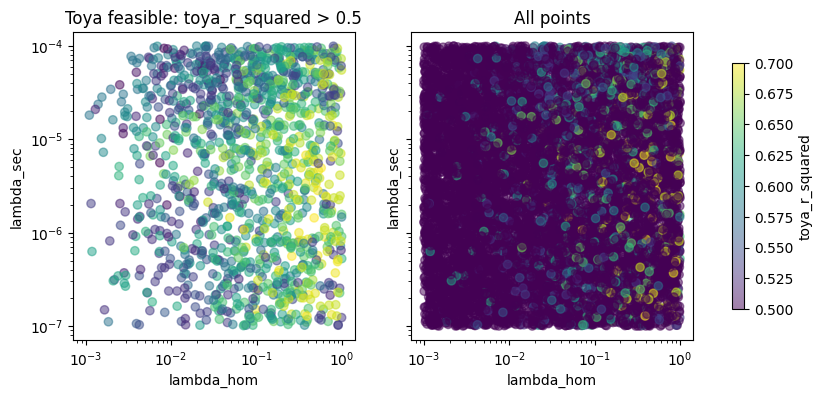

In [210]:
feasible = df["toya_r_squared"] > 0.5  # compute the mask once, reuse below
vmin, vmax = 0.5, 0.7

fig, axs = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)
plot_scatter(df["lambda_hom"][feasible], df["lambda_sec"][feasible],
             color=df["toya_r_squared"][feasible], vmin=vmin, vmax=vmax, ax=axs[0])
axs[0].set_title("Toya feasible: toya_r_squared > 0.5")

sc = plot_scatter(df["lambda_hom"], df["lambda_sec"], color=df["toya_r_squared"],
                   vmin=vmin, vmax=vmax, ax=axs[1])
axs[1].set_title("All points")

fig.colorbar(sc, ax=axs, label="toya_r_squared", shrink=0.8)
plt.show()

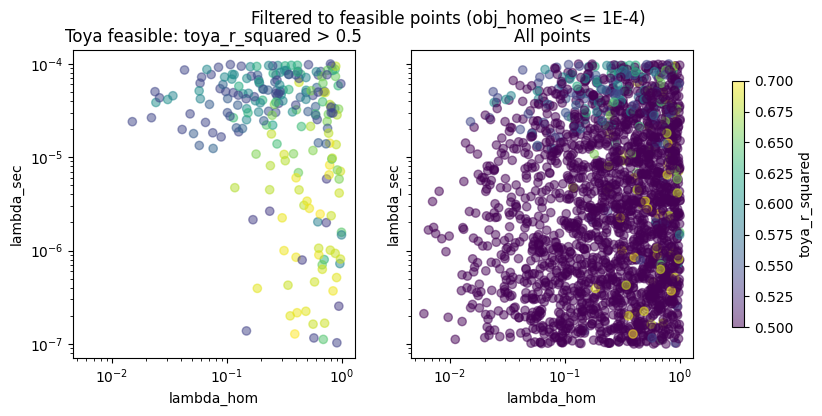

In [211]:
feasible = df_processed["toya_r_squared"] > 0.5  # compute the mask once, reuse below
vmin, vmax = 0.5, 0.7

fig, axs = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)
plot_scatter(df_processed["lambda_hom"][feasible], df_processed["lambda_sec"][feasible],
             color=df_processed["toya_r_squared"][feasible], vmin=vmin, vmax=vmax, ax=axs[0])
axs[0].set_title("Toya feasible: toya_r_squared > 0.5")

sc = plot_scatter(df_processed["lambda_hom"], df_processed["lambda_sec"], color=df_processed["toya_r_squared"],
                   vmin=vmin, vmax=vmax, ax=axs[1])
axs[1].set_title("All points")

fig.colorbar(sc, ax=axs, label="toya_r_squared", shrink=0.8)
fig.suptitle("Filtered to feasible points (obj_homeo <= 1E-4)")
plt.show()

In [212]:
from sklearn.linear_model import LinearRegression
# 1. Prepare sample data (X must be 2D)
X = np.log10(df_processed["lambda_hom"][feasible]).to_numpy().reshape(-1, 1)
y = np.log10(df_processed["lambda_sec"][feasible]).to_numpy().reshape(-1, 1)

# 2. Initialize and fit the model
model = LinearRegression()
model.fit(X, y)

# 3. View the results
print(f"Slope (Coefficient): {model.coef_[0][0]:.2f}")
print(f"Intercept: {model.intercept_[0]:.2f}")

Slope (Coefficient): -0.58
Intercept: -5.05


In [213]:
import statsmodels.api as sm
# 2. Statsmodels needs an explicit intercept (constant) column added to X
X_with_constant = sm.add_constant(X)

# 3. Fit the Ordinary Least Squares (OLS) model
model = sm.OLS(y, X_with_constant).fit()

# 4. Print the comprehensive statistical summary table
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.092
Model:                            OLS   Adj. R-squared:                  0.088
Method:                 Least Squares   F-statistic:                     22.31
Date:                Tue, 04 Aug 2026   Prob (F-statistic):           4.12e-06
Time:                        01:06:18   Log-Likelihood:                -244.77
No. Observations:                 223   AIC:                             493.5
Df Residuals:                     221   BIC:                             500.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -5.0473      0.080    -62.929      0.0

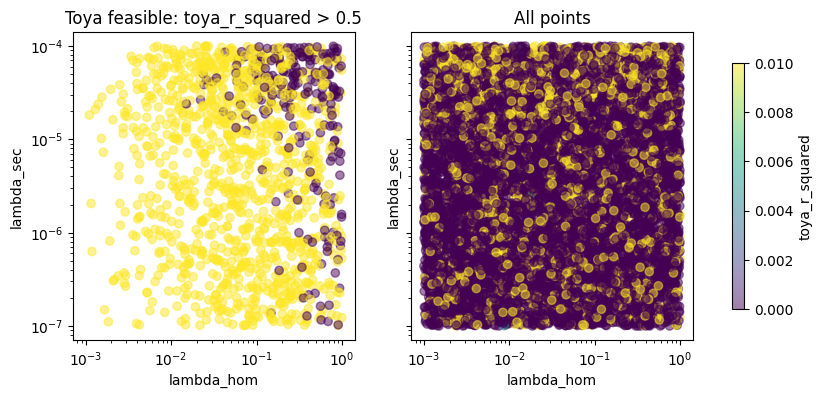

In [214]:
feasible = df["toya_r_squared"] > 0.5  # compute the mask once, reuse below
vmin, vmax = 0.5, 0.6

fig, axs = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)
plot_scatter(df["lambda_hom"][feasible], df["lambda_sec"][feasible],
             color=df["obj_homeo"][feasible], vmin=0, vmax=1E-4, ax=axs[0])
axs[0].set_title("Toya feasible: toya_r_squared > 0.5")

sc = plot_scatter(df["lambda_hom"], df["lambda_sec"], color=df["toya_r_squared"],
                   vmin=0, vmax=1E-2, ax=axs[1])
axs[1].set_title("All points")

fig.colorbar(sc, ax=axs, label="toya_r_squared", shrink=0.8)
plt.show()

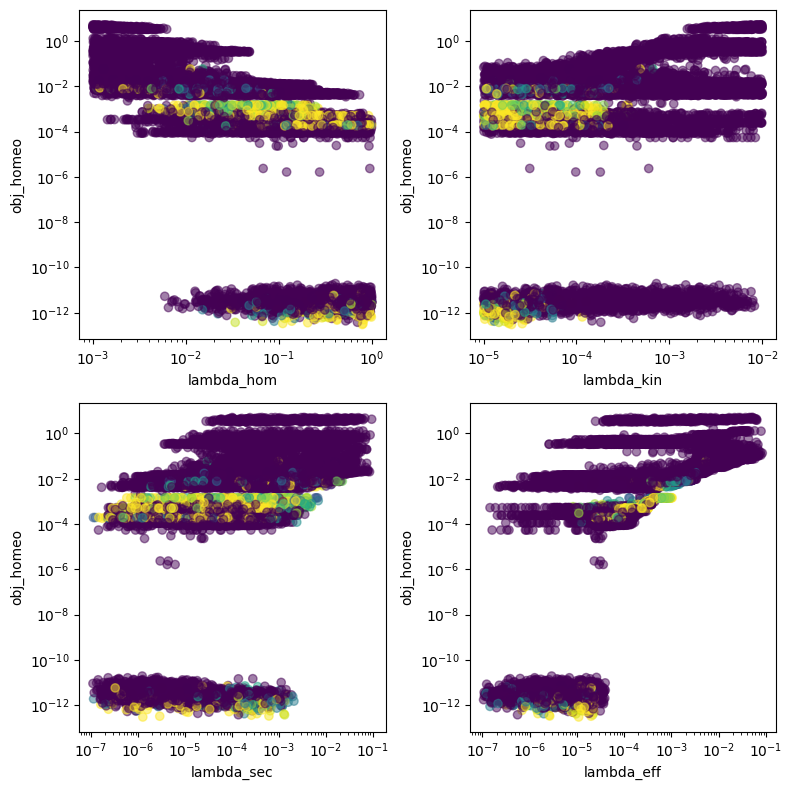

In [215]:
df_plot = df.copy()
fig, axs = plt.subplots(2, 2, figsize=(8, 8), sharex=False, sharey=False)
plot_scatter(df_plot["lambda_hom"], df_plot["obj_homeo"], color=df_plot["toya_r_squared"],
             x_label="lambda_hom", y_label="obj_homeo",log_x=True, log_y=True,
             vmin=0.5, vmax=0.6, ax=axs[0, 0])
plot_scatter(df_plot["lambda_kin"], df_plot["obj_homeo"], color=df_plot["toya_r_squared"],
             x_label="lambda_kin", y_label="obj_homeo",log_x=True, log_y=True,
             vmin=0.5, vmax=0.6, ax=axs[0, 1])
plot_scatter(df_plot["lambda_sec"]/df_plot["lambda_hom"], df_plot["obj_homeo"], color=df_plot["toya_r_squared"],
             x_label="lambda_sec", y_label="obj_homeo",log_x=True, log_y=True,
             vmin=0.5, vmax=0.6, ax=axs[1, 0])
plot_scatter(df_plot["lambda_eff"]/df_plot["lambda_hom"], df_plot["obj_homeo"], color=df_plot["toya_r_squared"],
             x_label="lambda_eff", y_label="obj_homeo",log_x=True, log_y=True,
             vmin=0.5, vmax=0.6, ax=axs[1, 1])
plt.tight_layout()
plt.show()

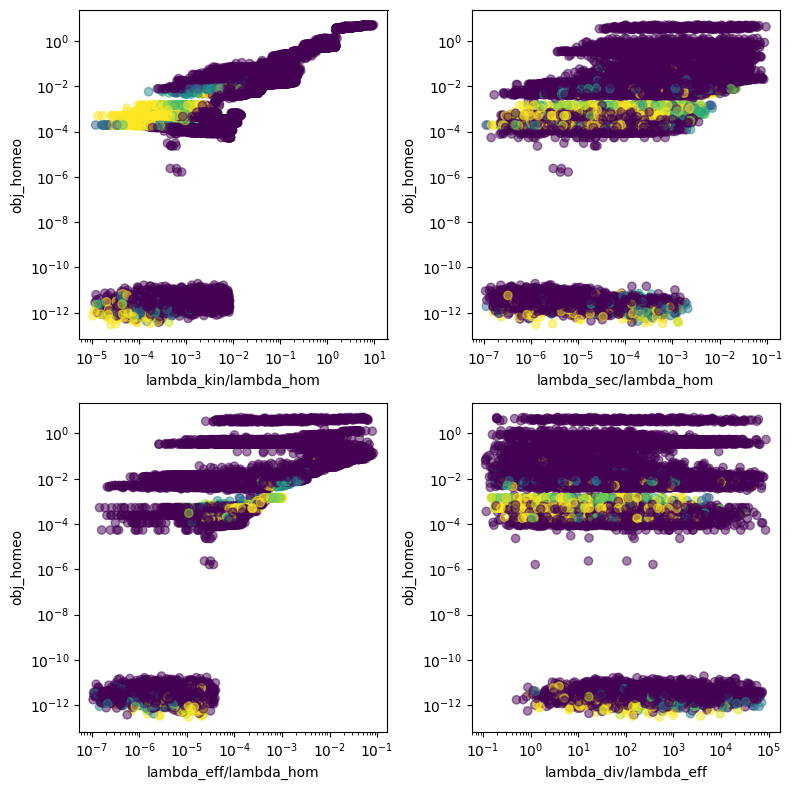

In [216]:
df_plot = df.copy()
fig, axs = plt.subplots(2, 2, figsize=(8, 8), sharex=False, sharey=False)
plot_scatter(df_plot["lambda_kin"]/df_plot["lambda_hom"], df_plot["obj_homeo"], color=df_plot["toya_r_squared"],
             x_label="lambda_kin/lambda_hom", y_label="obj_homeo",log_x=True, log_y=True,
             vmin=0.5, vmax=0.6, ax=axs[0, 0])
plot_scatter(df_plot["lambda_sec"]/df_plot["lambda_hom"], df_plot["obj_homeo"], color=df_plot["toya_r_squared"],
             x_label="lambda_sec/lambda_hom", y_label="obj_homeo",log_x=True, log_y=True,
             vmin=0.5, vmax=0.6, ax=axs[0, 1])
plot_scatter(df_plot["lambda_eff"]/df_plot["lambda_hom"], df_plot["obj_homeo"], color=df_plot["toya_r_squared"],
             x_label="lambda_eff/lambda_hom", y_label="obj_homeo",log_x=True, log_y=True,
             vmin=0.5, vmax=0.6, ax=axs[1, 0])
plot_scatter(df_plot["lambda_div"]/df_plot["lambda_eff"], df_plot["obj_homeo"], color=df_plot["toya_r_squared"],
             x_label="lambda_div/lambda_eff", y_label="obj_homeo",log_x=True, log_y=True,
             vmin=0.5, vmax=0.6, ax=axs[1, 1])
plt.tight_layout()
plt.show()

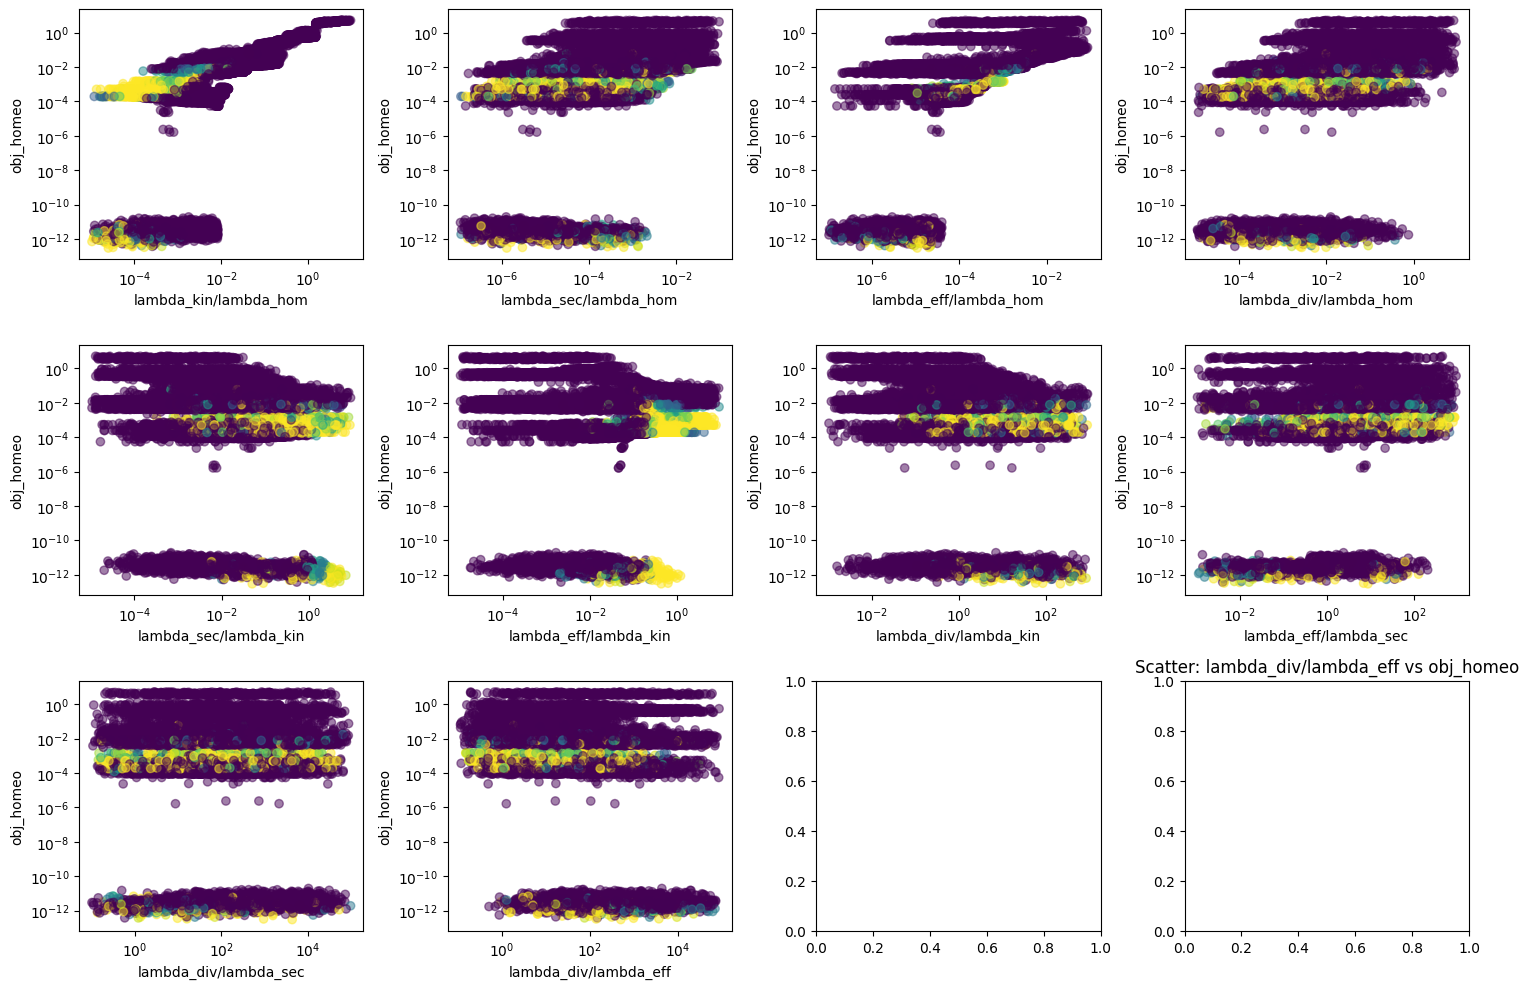

In [217]:
from itertools import combinations
df_plot = df.copy()
# df_plot = df_processed.copy()


weights = ['lambda_hom', 'lambda_kin', 'lambda_sec', 'lambda_eff', 'lambda_div']
pairs = list(combinations(weights, 2))

fig, ax = plt.subplots(3,4 , figsize=(15, 10), sharex=False, sharey=False)
for denom, numer in pairs:
    ratio = df_plot[numer] / df_plot[denom]
    x_label = f"{numer}/{denom}"
    y_label = "obj_homeo"

    plot_scatter(ratio, df_plot["obj_homeo"], color=df_plot["toya_r_squared"],
                 x_label=x_label, y_label=y_label, log_x=True, log_y=True,
                 vmin=0.5, vmax=0.6, ax=ax.flatten()[pairs.index((denom, numer))])
plt.title(f"Scatter: {x_label} vs {y_label}")
plt.tight_layout()
plt.show()


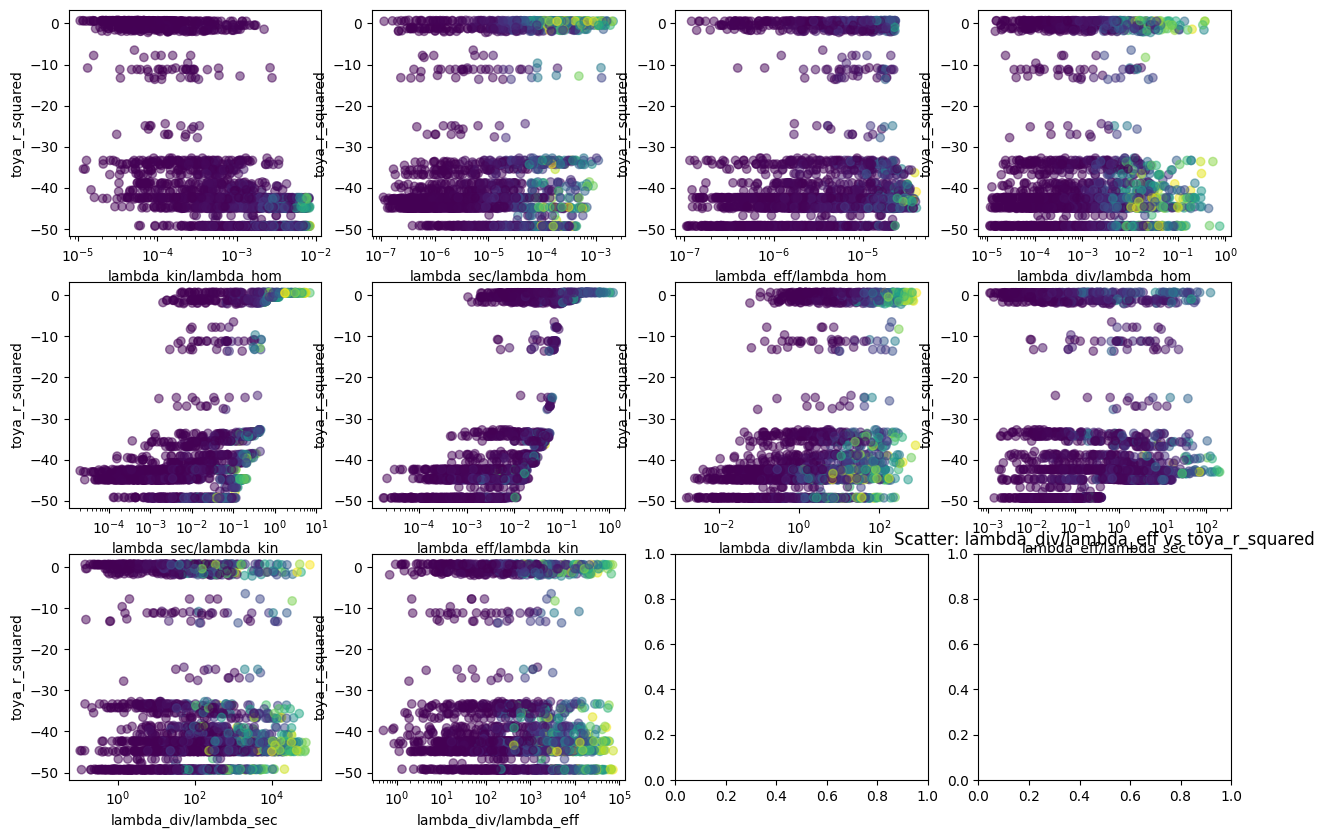

In [219]:
from itertools import combinations
df_plot = df.copy()
df_plot = df_processed.copy()

weights = ['lambda_hom', 'lambda_kin', 'lambda_sec', 'lambda_eff', 'lambda_div']
pairs = list(combinations(weights, 2))

fig, ax = plt.subplots(3,4 , figsize=(15, 10), sharex=False, sharey=False)
for denom, numer in pairs:
    ratio = df_plot[numer] / df_plot[denom]
    x_label = f"{numer}/{denom}"
    y_label = "toya_r_squared"

    plot_scatter(ratio, df_plot["toya_r_squared"], color=df_plot[numer],
                 x_label=x_label, y_label=y_label, log_x=True, log_y=False,
                 vmin=0, vmax=max(df_plot[numer]), ax=ax.flatten()[pairs.index((denom, numer))])
plt.title(f"Scatter: {x_label} vs {y_label}")
# plt.tight_layout()
plt.show()


# obj_hom < threshold points

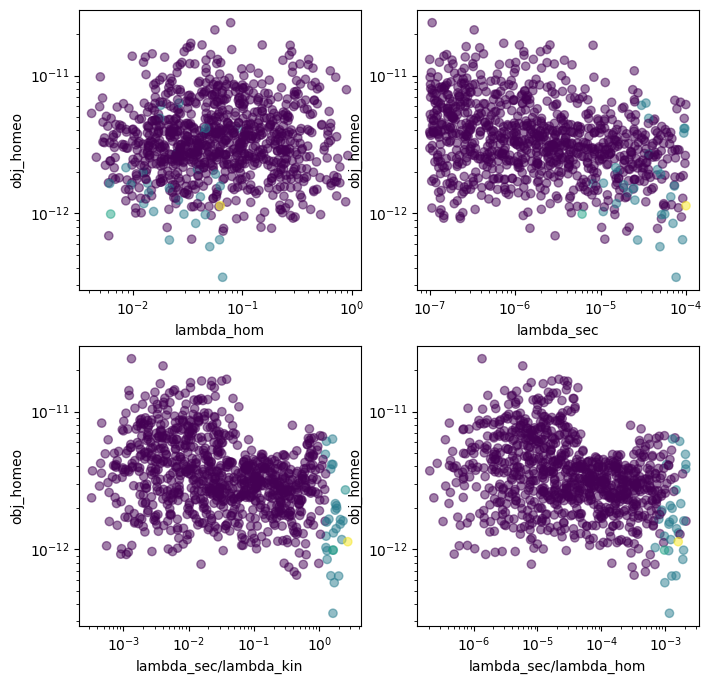

In [203]:
df_plot = df_processed.copy()
fig, axs = plt.subplots(2, 2, figsize=(8, 8), sharex=False, sharey=False)
plot_scatter(df_plot["lambda_hom"], df_plot["obj_homeo"], color=df_plot["toya_r_squared"],
             x_label="lambda_hom", y_label="obj_homeo",log_x=True, log_y=True,
             vmin=0.5, vmax=0.6, ax=axs[0, 0])
plot_scatter(df_plot["lambda_sec"], df_plot["obj_homeo"], color=df_plot["toya_r_squared"],
             x_label="lambda_sec", y_label="obj_homeo",log_x=True, log_y=True,
             vmin=0.5, vmax=0.6, ax=axs[0, 1])
plot_scatter(df_plot["lambda_sec"]/df_plot["lambda_kin"], df_plot["obj_homeo"], color=df_plot["toya_r_squared"],
             x_label="lambda_sec/lambda_kin", y_label="obj_homeo",log_x=True, log_y=True,
             vmin=0.5, vmax=0.6, ax=axs[1, 0])
plot_scatter(df_plot["lambda_sec"]/df_plot["lambda_hom"], df_plot["obj_homeo"], color=df_plot["toya_r_squared"],
             x_label="lambda_sec/lambda_hom", y_label="obj_homeo",log_x=True, log_y=True,
             vmin=0.5, vmax=0.6, ax=axs[1, 1])
plt.show()

In [205]:
df_temp['lambda_sec/lambda_kin'] = df_temp['lambda_sec'] / df_temp['lambda_kin']
print(min(df_temp['lambda_sec/lambda_kin']), max(df_temp['lambda_sec/lambda_kin']))

1.2441961923670035 2.7372078947293086


0.0006923245309507078 0.0020889917238123383


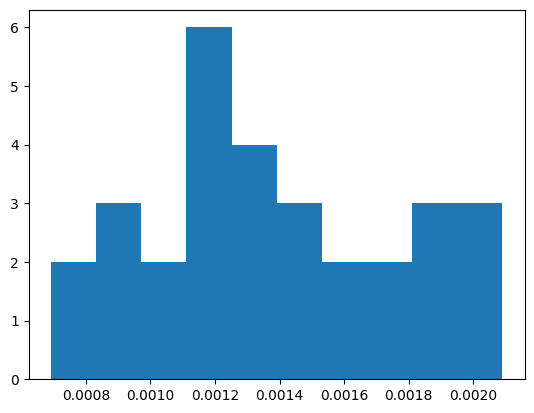

In [113]:
df_temp = df_plot.query("toya_r_squared > 0.5").copy()
df_temp['lambda_sec/lambda_hom'] = df_temp['lambda_sec'] / df_temp['lambda_hom']
plt.hist(df_temp['lambda_sec/lambda_hom'])
print(min(df_temp['lambda_sec/lambda_hom']), max(df_temp['lambda_sec/lambda_hom']))

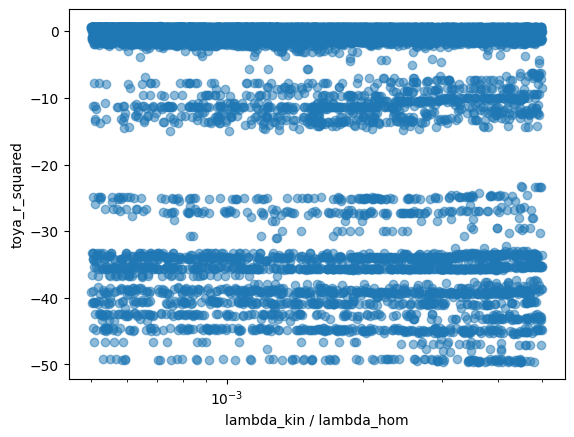

In [105]:
# Ratio example: x_label must be passed explicitly since arithmetic between
# two differently-named Series drops .name.
plot_scatter(df["lambda_kin"] / df["lambda_hom"], df["toya_r_squared"],
             x_label="lambda_kin / lambda_hom", log_x=True, log_y=False)
plt.show()

In [106]:
df.sort_values(by = "toya_r_squared", ascending=False).head(10)

,lambda_hom,lambda_sec,lambda_eff,lambda_kin,lambda_div,fraction_kinetic_target,obj_total,obj_homeo,obj_kin,obj_eff,obj_sec,obj_div,obj_hom_w,obj_kin_w,obj_eff_w,obj_sec_w,obj_div_w,toya_pearson_r_squared,toya_r_squared
7161,0.022278,2.763862e-07,5.272016e-06,0.000016,0.000802,1.0,0.001125,0.000493,24.550247,137.361867,2.644929,0.001828,0.000011,0.000388,0.000724,7.310219e-07,1.466476e-06,0.839692,0.765860
4009,0.068655,2.551171e-05,1.732468e-05,0.000090,0.000797,1.0,0.004641,0.000736,22.904022,141.609793,2.896073,0.001838,0.000051,0.002062,0.002453,7.388377e-05,1.464947e-06,0.740488,0.685809
4453,0.095798,3.334235e-07,2.807342e-05,0.000085,0.000518,1.0,0.005985,0.000739,23.005246,141.086184,2.974182,0.001866,0.000071,0.001951,0.003961,9.916620e-07,9.675145e-07,0.740224,0.685607
5718,0.001973,1.277085e-07,6.008009e-07,0.000002,0.000282,1.0,0.000134,0.000764,22.993683,141.042472,2.980336,0.001828,0.000002,0.000046,0.000085,3.806141e-07,5.153547e-07,0.739260,0.684308
4110,0.009223,1.062922e-06,1.772024e-06,0.000007,0.008067,1.0,0.000436,0.000491,23.072097,141.796481,2.997311,0.001828,0.000005,0.000162,0.000251,3.185909e-06,1.474615e-05,0.741569,0.683574
1362,0.071803,1.476584e-05,9.278474e-06,0.000050,0.004445,1.0,0.002561,0.000488,22.978018,142.299647,2.911432,0.001828,0.000035,0.001154,0.001320,4.298973e-05,8.124713e-06,0.741610,0.683563
5286,0.226405,1.096398e-05,4.275748e-05,0.000144,0.006445,1.0,0.009531,0.000491,23.073251,141.792855,2.996003,0.001828,0.000111,0.003313,0.006063,3.284811e-05,1.178195e-05,0.741506,0.683558
2268,0.148011,3.150989e-06,2.608897e-05,0.000082,0.000014,1.0,0.005675,0.000491,23.080410,141.761816,2.988315,0.006362,0.000073,0.001895,0.003698,9.416145e-06,8.774329e-08,0.741134,0.683452
8171,0.117497,1.304864e-06,3.178072e-05,0.000098,0.001796,1.0,0.006833,0.000605,23.037589,141.476568,2.989510,0.001834,0.000071,0.002259,0.004496,3.900905e-06,3.294383e-06,0.739920,0.683152
4450,0.336300,6.125026e-05,7.735735e-05,0.000324,0.002409,1.0,0.018786,0.000490,23.072564,141.834598,2.935142,0.001848,0.000165,0.007465,0.010972,1.797782e-04,4.452228e-06,0.739689,0.682128
